# Brain Tumor MRI

## Setting

In [92]:
import os
import sys
import time
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [93]:
sys.path.append(os.getcwd())

In [94]:
from model.simple_cnn import SimpleCNN
from model.resnet18 import get_resnet18
from model.efficientnet import get_efficientnet_b0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch.backends.cudnn.benchmark = True

Using device: cuda
GPU: NVIDIA RTX A6000


## Parameters

In [95]:
train_dir = "data/Training"
test_dir = "data/Testing"

img_size = 224
batch_size = 32
num_classes = 4
val_ratio = 0.2
random_seed = 42

In [96]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.0, save_path="best_model.pth"):
        """
        patience: validation loss 幾次沒有改善後停止
        min_delta: 至少要改善多少才算有進步
        save_path: 儲存最佳模型的位置
        """
        self.patience = patience
        self.min_delta = min_delta
        self.save_path = save_path

        self.best_loss = float("inf")
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.save_path)
            print(f"Validation loss improved. Model saved to {self.save_path}")
        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")

            if self.counter >= self.patience:
                self.early_stop = True

## Data Loading

In [97]:
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
])

full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

print("Classes:", full_train_dataset.classes)
print("Class to idx:", full_train_dataset.class_to_idx)
print("Full training data size:", len(full_train_dataset))
print("Testing data size:", len(test_dataset))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class to idx: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Full training data size: 5600
Testing data size: 1600


In [98]:
train_size = int((1 - val_ratio) * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(random_seed)
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=generator)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Train size: 4480
Val size: 1120


In [99]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

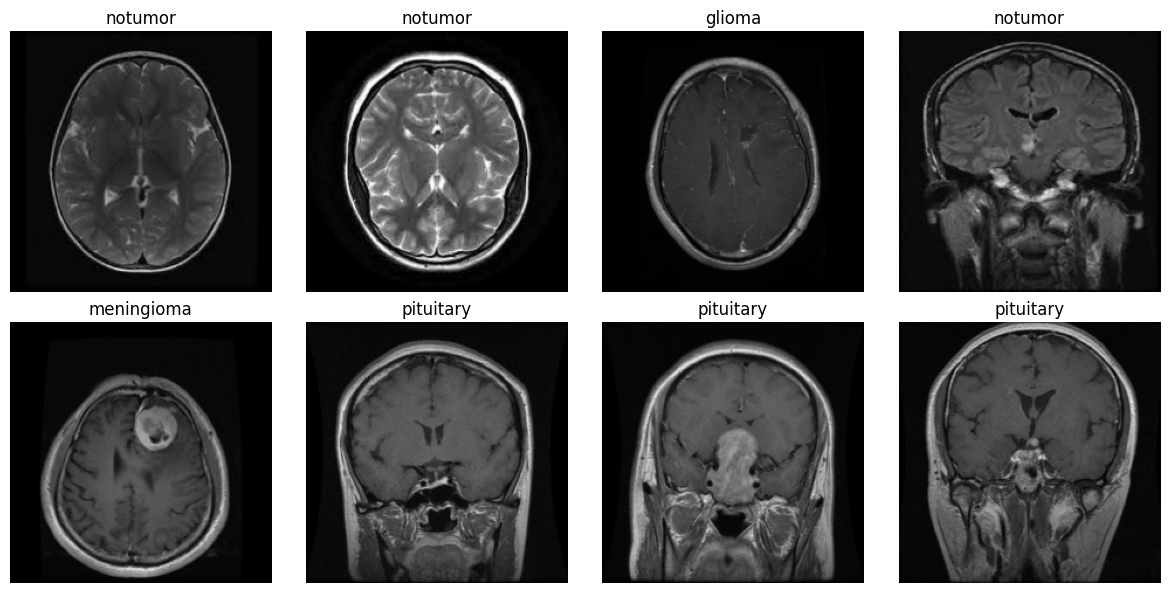

In [100]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(full_train_dataset.classes[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## CNN

In [80]:
model = SimpleCNN(num_classes=num_classes).to(device)

lr = 3e-4
num_epochs = 100

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(
    model.parameters(),
    lr=lr,
    weight_decay=1e-4,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)


### Training

In [81]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)

        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels).item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * images.size(0)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

In [82]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_train_acc = 0.0
best_train_loss = float("inf")
best_val_acc = 0.0
best_val_loss = float("inf")

save_dir = "checkpoints"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "best_simplecnn.pth")

early_stopping = EarlyStopping(
    patience=7,
    min_delta=0.001,
    save_path=best_model_path
)

start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_train_loss = train_loss
        best_train_acc = train_acc

    early_stopping(val_loss, model)

    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break

elapsed = time.time() - start_time

print(f"\nTraining finished in {elapsed:.2f} seconds")
print(f"Best Train Loss: {best_train_loss:.4f}")
print(f"Best Train Acc: {best_train_acc:.4f}")
print(f"Best Val Loss: {best_val_loss:.4f}")
print(f"Best Val Acc: {best_val_acc:.4f}")

model.load_state_dict(torch.load(best_model_path, map_location=device))
model = model.to(device)

Epoch [1/100] Train Loss: 0.9298 | Train Acc: 0.6837 | Val Loss: 0.7426 | Val Acc: 0.8036 | LR: 0.000300
Validation loss improved. Model saved to checkpoints/best_simplecnn.pth
Epoch [2/100] Train Loss: 0.7118 | Train Acc: 0.8286 | Val Loss: 0.6435 | Val Acc: 0.8580 | LR: 0.000300
Validation loss improved. Model saved to checkpoints/best_simplecnn.pth
Epoch [3/100] Train Loss: 0.6360 | Train Acc: 0.8694 | Val Loss: 0.5904 | Val Acc: 0.8732 | LR: 0.000300
Validation loss improved. Model saved to checkpoints/best_simplecnn.pth
Epoch [4/100] Train Loss: 0.5783 | Train Acc: 0.9009 | Val Loss: 0.5546 | Val Acc: 0.8964 | LR: 0.000300
Validation loss improved. Model saved to checkpoints/best_simplecnn.pth
Epoch [5/100] Train Loss: 0.5335 | Train Acc: 0.9275 | Val Loss: 0.5443 | Val Acc: 0.9045 | LR: 0.000300
Validation loss improved. Model saved to checkpoints/best_simplecnn.pth
Epoch [6/100] Train Loss: 0.5052 | Train Acc: 0.9444 | Val Loss: 0.5244 | Val Acc: 0.9214 | LR: 0.000300
Validation

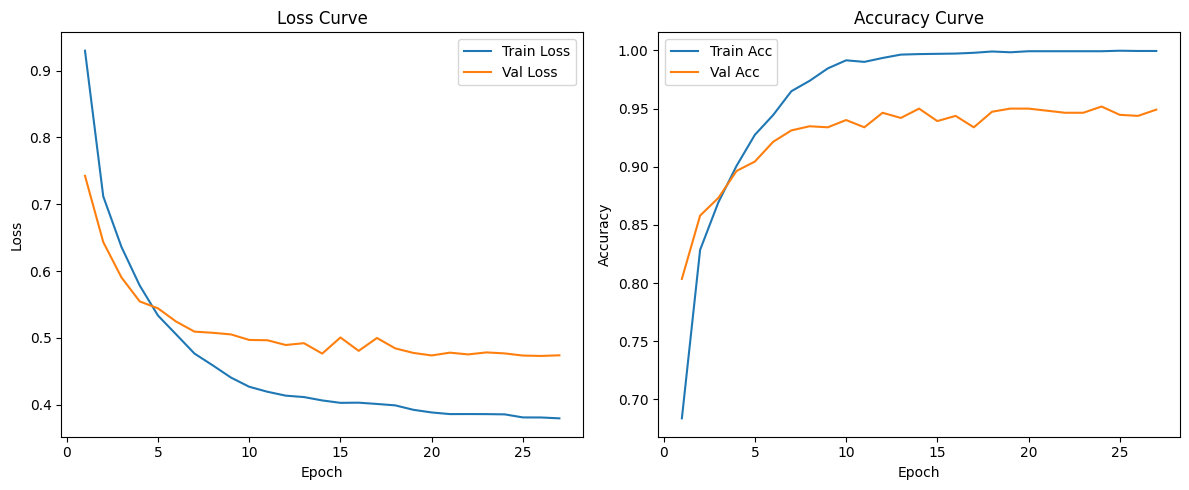

In [83]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

### Evaluate

In [84]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"{best_train_loss:.4f}\t{best_train_acc:.4f}\t{best_val_loss:.4f}\t{best_val_acc:.4f}\t{test_loss:.4f}\t{test_acc:.4f}")

0.3810	0.9996	0.4730	0.9437	0.5981	0.8938


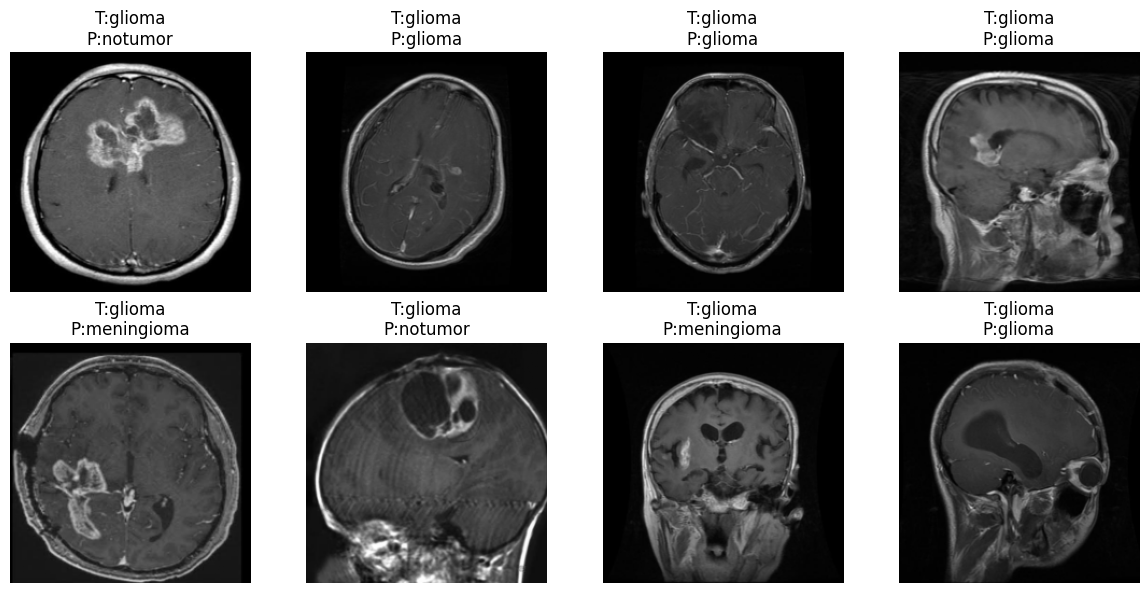

In [85]:
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(f"T:{full_train_dataset.classes[labels[i]]}\nP:{full_train_dataset.classes[preds[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Resnet18

In [74]:
model = get_resnet18(num_classes=num_classes).to(device)

lr = 3e-4
num_epochs = 100

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(
    model.parameters(),
    lr=lr,
    weight_decay=1e-4,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

### Training

In [75]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)

        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels).item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * images.size(0)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

In [76]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_train_acc = 0.0
best_train_loss = float("inf")
best_val_acc = 0.0
best_val_loss = float("inf")

save_dir = "checkpoints"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "best_resnet18.pth")

early_stopping = EarlyStopping(
    patience=7,
    min_delta=0.001,
    save_path=best_model_path
)

start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_train_loss = train_loss
        best_train_acc = train_acc

    early_stopping(val_loss, model)

    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break

elapsed = time.time() - start_time

print(f"\nTraining finished in {elapsed:.2f} seconds")
print(f"Best Train Loss: {best_train_loss:.4f}")
print(f"Best Train Acc: {best_train_acc:.4f}")
print(f"Best Val Loss: {best_val_loss:.4f}")
print(f"Best Val Acc: {best_val_acc:.4f}")

model.load_state_dict(torch.load(best_model_path, map_location=device))
model = model.to(device)

Epoch [1/100] Train Loss: 0.5314 | Train Acc: 0.9208 | Val Loss: 0.5766 | Val Acc: 0.8911 | LR: 0.000300
Validation loss improved. Model saved to checkpoints/best_resnet18.pth
Epoch [2/100] Train Loss: 0.4074 | Train Acc: 0.9821 | Val Loss: 0.4394 | Val Acc: 0.9598 | LR: 0.000300
Validation loss improved. Model saved to checkpoints/best_resnet18.pth
Epoch [3/100] Train Loss: 0.3800 | Train Acc: 0.9951 | Val Loss: 0.4163 | Val Acc: 0.9714 | LR: 0.000300
Validation loss improved. Model saved to checkpoints/best_resnet18.pth
Epoch [4/100] Train Loss: 0.3720 | Train Acc: 0.9967 | Val Loss: 0.4012 | Val Acc: 0.9821 | LR: 0.000300
Validation loss improved. Model saved to checkpoints/best_resnet18.pth
Epoch [5/100] Train Loss: 0.3684 | Train Acc: 0.9962 | Val Loss: 0.4121 | Val Acc: 0.9723 | LR: 0.000300
EarlyStopping counter: 1/7
Epoch [6/100] Train Loss: 0.3610 | Train Acc: 0.9987 | Val Loss: 0.3740 | Val Acc: 0.9911 | LR: 0.000300
Validation loss improved. Model saved to checkpoints/best_r

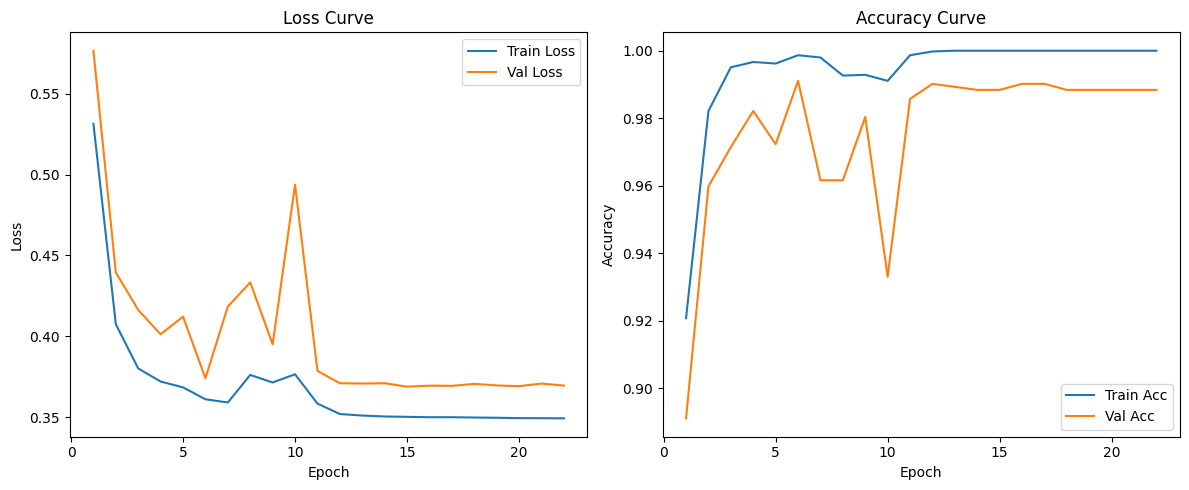

In [77]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

### Evaluate

In [78]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"{best_train_loss:.4f}\t{best_train_acc:.4f}\t{best_val_loss:.4f}\t{best_val_acc:.4f}\t{test_loss:.4f}\t{test_acc:.4f}")

0.3501	1.0000	0.3688	0.9884	0.4761	0.9475


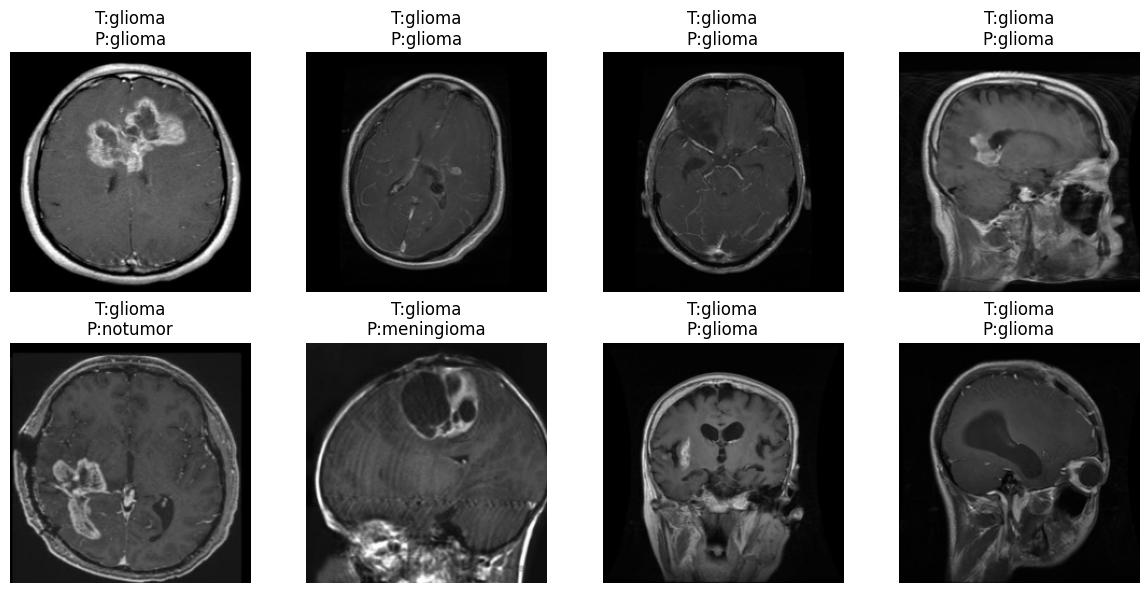

In [79]:
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(f"T:{full_train_dataset.classes[labels[i]]}\nP:{full_train_dataset.classes[preds[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Efficientnet

In [68]:
model = get_resnet18(num_classes=num_classes).to(device)

lr = 3e-4
num_epochs = 100

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(
    model.parameters(),
    lr=lr,
    weight_decay=1e-4,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

### Training

In [69]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)

        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels).item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * images.size(0)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

In [70]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_train_acc = 0.0
best_train_loss = float("inf")
best_val_acc = 0.0
best_val_loss = float("inf")

save_dir = "checkpoints"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "best_efficientnet_b0.pth")

early_stopping = EarlyStopping(
    patience=7,
    min_delta=0.001,
    save_path=best_model_path
)

start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_train_loss = train_loss
        best_train_acc = train_acc

    early_stopping(val_loss, model)

    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break

elapsed = time.time() - start_time

print(f"\nTraining finished in {elapsed:.2f} seconds")
print(f"Best Train Loss: {best_train_loss:.4f}")
print(f"Best Train Acc: {best_train_acc:.4f}")
print(f"Best Val Loss: {best_val_loss:.4f}")
print(f"Best Val Acc: {best_val_acc:.4f}")

model.load_state_dict(torch.load(best_model_path, map_location=device))
model = model.to(device)

Epoch [1/100] Train Loss: 0.5450 | Train Acc: 0.9100 | Val Loss: 0.4600 | Val Acc: 0.9554 | LR: 0.000300
Validation loss improved. Model saved to checkpoints/best_efficientnet_b0.pth
Epoch [2/100] Train Loss: 0.3993 | Train Acc: 0.9871 | Val Loss: 0.4148 | Val Acc: 0.9732 | LR: 0.000300
Validation loss improved. Model saved to checkpoints/best_efficientnet_b0.pth
Epoch [3/100] Train Loss: 0.3833 | Train Acc: 0.9911 | Val Loss: 0.3985 | Val Acc: 0.9795 | LR: 0.000300
Validation loss improved. Model saved to checkpoints/best_efficientnet_b0.pth
Epoch [4/100] Train Loss: 0.3710 | Train Acc: 0.9953 | Val Loss: 0.4022 | Val Acc: 0.9821 | LR: 0.000300
EarlyStopping counter: 1/7
Epoch [5/100] Train Loss: 0.3626 | Train Acc: 0.9978 | Val Loss: 0.3984 | Val Acc: 0.9812 | LR: 0.000300
EarlyStopping counter: 2/7
Epoch [6/100] Train Loss: 0.3641 | Train Acc: 0.9967 | Val Loss: 0.3733 | Val Acc: 0.9902 | LR: 0.000300
Validation loss improved. Model saved to checkpoints/best_efficientnet_b0.pth
Epoc

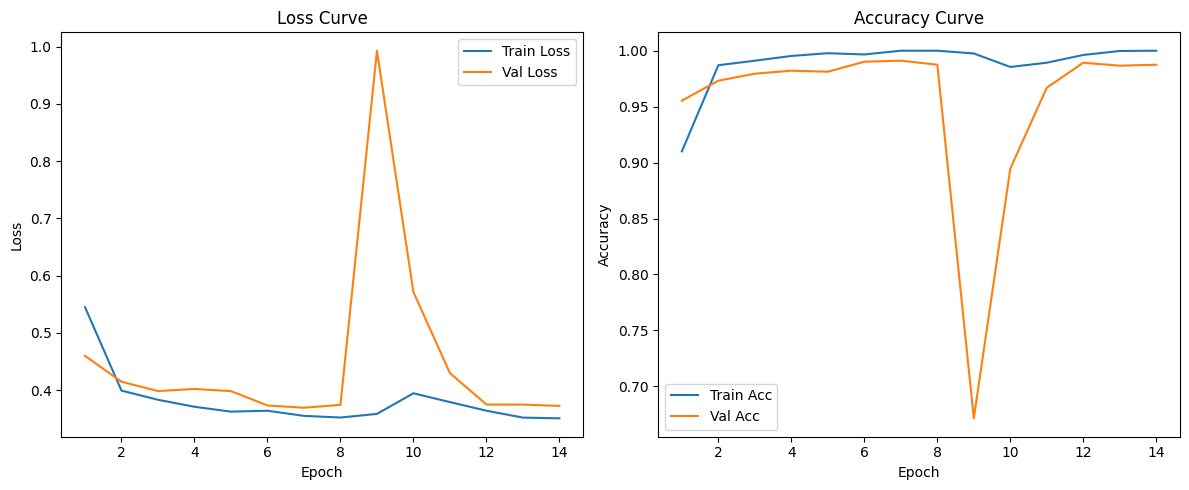

In [71]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

### Evaluate

In [72]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"{best_train_loss:.4f}\t{best_train_acc:.4f}\t{best_val_loss:.4f}\t{best_val_acc:.4f}\t{test_loss:.4f}\t{test_acc:.4f}")

0.3552	1.0000	0.3694	0.9911	0.4942	0.9450


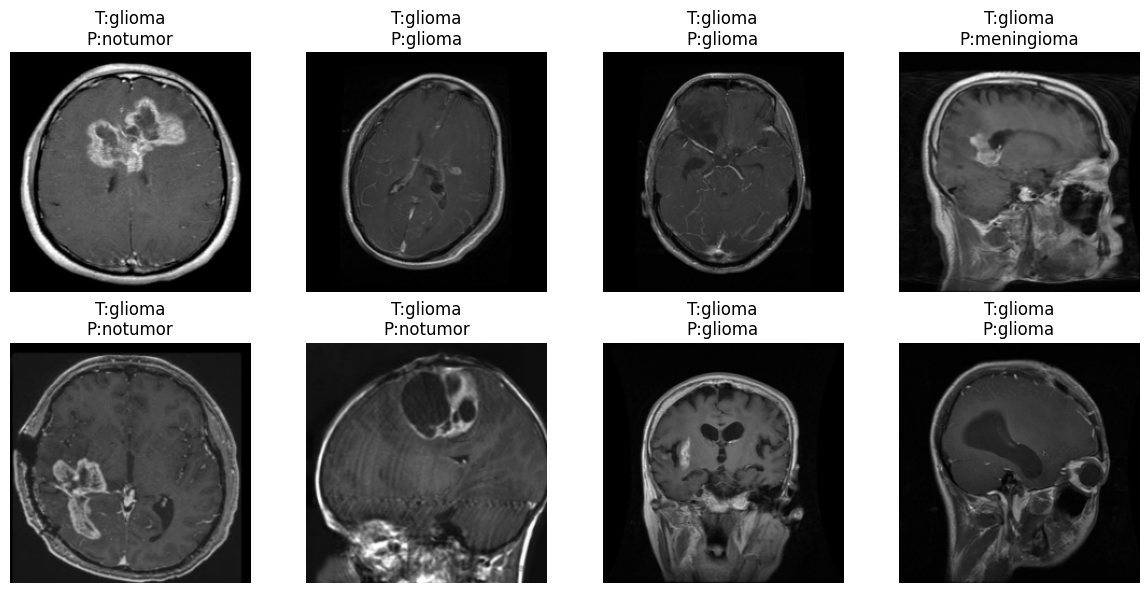

In [73]:
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(f"T:{full_train_dataset.classes[labels[i]]}\nP:{full_train_dataset.classes[preds[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## VGG

In [86]:
model = SimpleCNN(num_classes=num_classes).to(device)

lr = 1e-3
num_epochs = 50

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.SGD(
    model.parameters(),
    lr=lr,
    weight_decay=1e-4,
    momentum=0.9
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)


### Training

In [87]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)

        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels).item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * images.size(0)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

In [88]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_train_acc = 0.0
best_train_loss = float("inf")
best_val_acc = 0.0
best_val_loss = float("inf")

save_dir = "checkpoints"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "best_simplecnn.pth")

early_stopping = EarlyStopping(
    patience=7,
    min_delta=0.001,
    save_path=best_model_path
)

start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_train_loss = train_loss
        best_train_acc = train_acc

    early_stopping(val_loss, model)

    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break

elapsed = time.time() - start_time

print(f"\nTraining finished in {elapsed:.2f} seconds")
print(f"Best Train Loss: {best_train_loss:.4f}")
print(f"Best Train Acc: {best_train_acc:.4f}")
print(f"Best Val Loss: {best_val_loss:.4f}")
print(f"Best Val Acc: {best_val_acc:.4f}")

model.load_state_dict(torch.load(best_model_path, map_location=device))
model = model.to(device)

Epoch [1/50] Train Loss: 1.3650 | Train Acc: 0.3295 | Val Loss: 1.3122 | Val Acc: 0.3625 | LR: 0.001000
Validation loss improved. Model saved to checkpoints/best_simplecnn.pth
Epoch [2/50] Train Loss: 1.1415 | Train Acc: 0.5592 | Val Loss: 0.9655 | Val Acc: 0.6438 | LR: 0.001000
Validation loss improved. Model saved to checkpoints/best_simplecnn.pth
Epoch [3/50] Train Loss: 0.9388 | Train Acc: 0.6904 | Val Loss: 0.8726 | Val Acc: 0.7348 | LR: 0.001000
Validation loss improved. Model saved to checkpoints/best_simplecnn.pth
Epoch [4/50] Train Loss: 0.8799 | Train Acc: 0.7292 | Val Loss: 0.8394 | Val Acc: 0.7366 | LR: 0.001000
Validation loss improved. Model saved to checkpoints/best_simplecnn.pth
Epoch [5/50] Train Loss: 0.8383 | Train Acc: 0.7462 | Val Loss: 0.7890 | Val Acc: 0.7821 | LR: 0.001000
Validation loss improved. Model saved to checkpoints/best_simplecnn.pth
Epoch [6/50] Train Loss: 0.8045 | Train Acc: 0.7750 | Val Loss: 0.7739 | Val Acc: 0.8054 | LR: 0.001000
Validation loss 

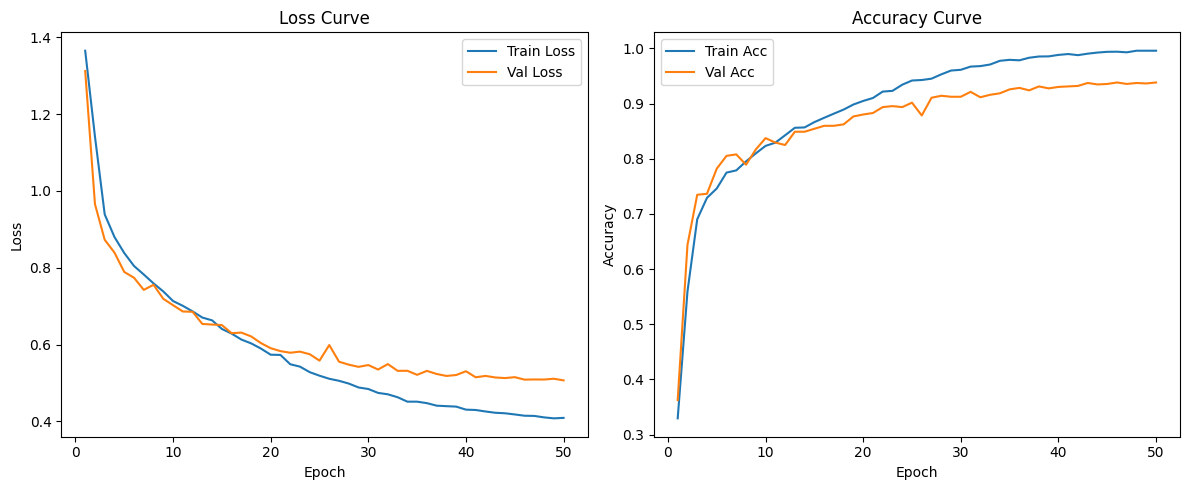

In [89]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

### Evaluate

In [90]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"{best_train_loss:.4f}\t{best_train_acc:.4f}\t{best_val_loss:.4f}\t{best_val_acc:.4f}\t{test_loss:.4f}\t{test_acc:.4f}")

0.4091	0.9960	0.5067	0.9384	0.6564	0.8819


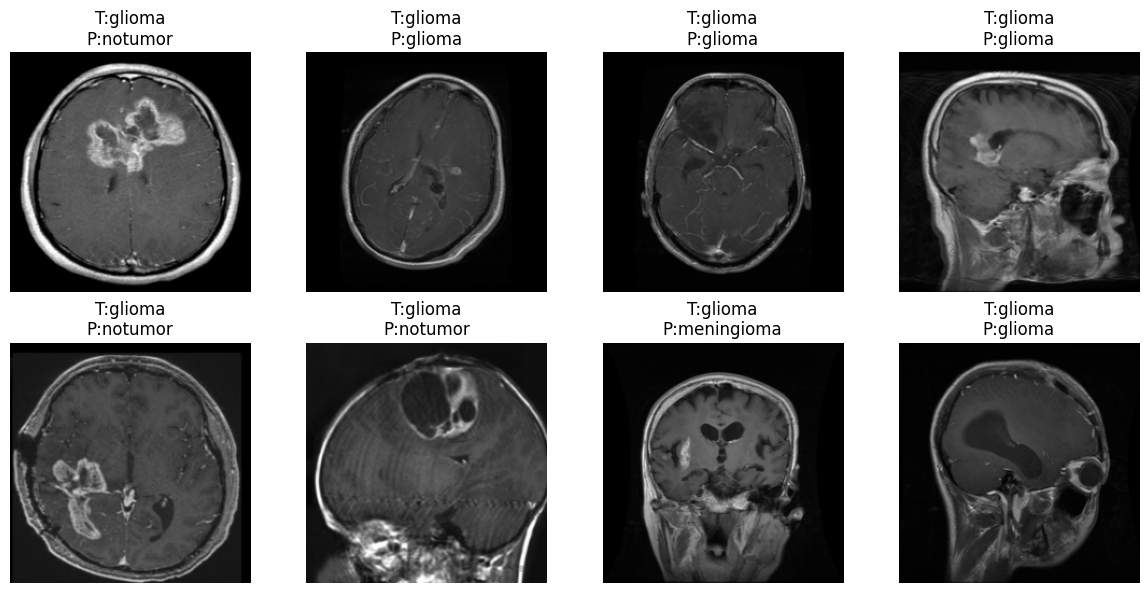

In [91]:
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(f"T:{full_train_dataset.classes[labels[i]]}\nP:{full_train_dataset.classes[preds[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()